In [93]:
import math

class Value:
    def __init__(self,data,_children=(),_op='',label=""):
        self.data = data
        self.grad = 0.0
        self._prev = _children
        self._op = _op
        self.label = label
        self._backward = lambda:None

    def __add__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data + other.data, (self,other),"+")

        def _backward():
            self.grad += out.grad
            other.grad += out.grad

        out._backward = _backward

        return out 
    
    def __radd__(self, other):
        return self + other
    
    def __mul__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data * other.data,(self,other),"*")

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self * other

    def __repr__(self):
        return f"Value: {self.data}"
    
    def __iter__(self):
        for child in self._prev:
            yield child
    
    def tanh(self):
        x = self.data
        t = math.tanh(x)
        out = Value(t,(self,),"tanh")

        def _backward():
            self.grad = (1-t**2) * out.grad

        out._backward = _backward
        return out
        

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        self.grad = 1.0

        for node in reversed(topo):
            node._backward()



In [94]:
v1 = Value(2);v1.label = 'v1'
v2 = Value(3);v2.label = 'v2'
v3 = v1+v2;v3.label = 'v3'
b = Value(4) ;b.label = 'b'
v4 = v3+b ; v4.label = 'v4'
v5 = v4.tanh()
v5; v5.label = "v5"

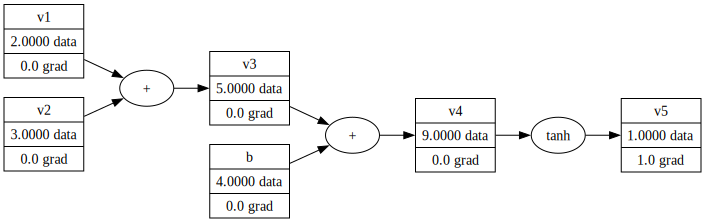

In [102]:
v5.backward()
draw_dots(v5)

In [95]:
def trace(root):
    nodes,edges = set(),set()
    def build(v):
        if not v in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    
    return nodes,edges

from graphviz import Digraph

def draw_dots(root):
    dot = Digraph(name="graph",format='svg',graph_attr={"rankdir":"LR"})

    nodes,edges = trace(root)

    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid,label='%s | %.4f data | %.1f grad' % (n.label,n.data,n.grad),shape='record',)

        if n._op:
            dot.node(name=uid+n._op,label=n._op)
            dot.edge(uid+n._op,uid)

    for e1,e2 in edges:
        dot.edge(str(id(e1)),str(id(e2)) + e2._op)

    return dot
    

In [96]:
import random
class Neuron:
    def __init__(self,nin):
        self.w = [Value(random.uniform(-1,1)) for i in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self,x):
        # wx+b 

        act = sum((wi*xi for wi,xi in zip(self.w,x)),self.b) 
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]        
    

    def state_dict(self):
        return {
            "weights":self.w,
            "bias":[self.b]
        }

class Layer:
    def __init__(self,nin,nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self,x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs)==1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
    
    def state_dict(self):
        return {k:v for neuron in self.neurons for k,v in neuron.state_dict().items()}
    

class MLP:
    def __init__(self,nin,nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nouts))]

    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [l for layer in self.layers for l in layer.parameters()]
    
    def state_dict(self):
        return {k:v for layer in self.layers for k,v in layer.state_dict().items()}


In [97]:
x = [1.0,2.0]
n = MLP(3,[4,4,1])
n(x)

Value: 0.4605586353445342

In [98]:
len(n.parameters()) #,n.state_dict()

41

In [ ]:
n(x).backward()
draw_dots(n(x))

In [ ]:
# inputs x1 x2
x1 = Value(2.0,label='x1')
x2 = Value(0.0,label='x2')

# weights w1 w2
w1 = Value(-3.0,label="w1")
w2 = Value(1.0,label="w2")

# bias of the neuron
b = Value(6.8813735870195432,label="b")

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = "x1*w1"
x2w2 = x2*w2 ; x2w2.label = "x2*w2"

x1w1x2w2 = x1w1 + x2w2 ; x1w1x2w2.label = "x1w1 + x2w2"

n = x1w1x2w2 + b ; n.label = "n"


o = n.tanh() ; o.label = "o"

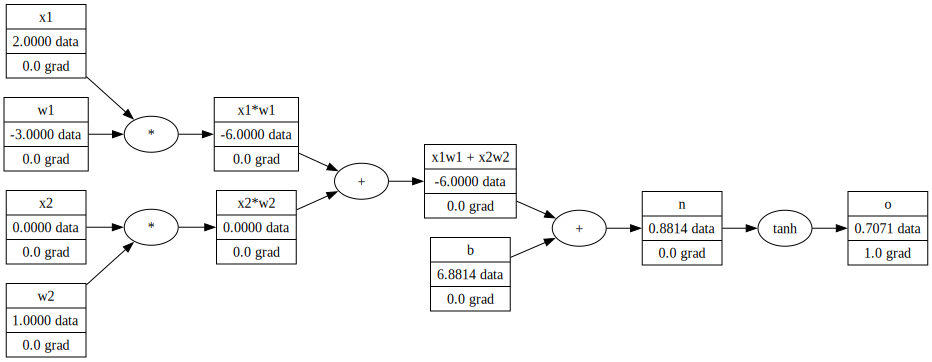

In [106]:
o.backward()
draw_dots(o)